In [10]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('Patrimoine_Arbore_Nettoye.csv')
data.head()

,clc_quartier,clc_secteur,haut_tot,haut_tronc,tronc_diam,fk_arb_etat,fk_stadedev,fk_port,fk_pied,fk_situation,...,dte_plantation,age_estim,fk_prec_estim,dte_abattage,fk_nomtech,villeca,feuillage,remarquable,long,lat
0,Quartier du Centre-Ville,Boulevard Richelieu,1200,300.0,100,SUPPRIMÉ,Non renseigné,Non renseigné,Non renseigné,Alignement,...,Non renseigné,30,10.0,2015/07/01 00:00:00+00,RAS,VILLE,Non renseigné,Non,3.282540,49.850458
1,Quartier du Centre-Ville,Boulevard Léon Blum,1200,300.0,100,ABATTU,Non renseigné,Non renseigné,Non renseigné,Alignement,...,Non renseigné,30,10.0,Non renseigné,RAS,VILLE,Non renseigné,Non,3.290521,49.840654
2,Quartier du Centre-Ville,Boulevard Léon Blum,1200,300.0,100,SUPPRIMÉ,Non renseigné,Non renseigné,Non renseigné,Alignement,...,Non renseigné,30,10.0,Non renseigné,RAS,VILLE,Non renseigné,Non,3.290460,49.840756
3,Quartier du Centre-Ville,Boulevard Léon Blum,1200,300.0,100,SUPPRIMÉ,Non renseigné,Non renseigné,Non renseigné,Alignement,...,Non renseigné,30,10.0,Non renseigné,RAS,VILLE,Non renseigné,Non,3.290568,49.840783
4,Quartier du Centre-Ville,Boulevard Léon Blum,1200,300.0,100,ABATTU,Non renseigné,Non renseigné,Non renseigné,Alignement,...,Non renseigné,30,10.0,Non renseigné,RAS,VILLE,Non renseigné,Non,3.293178,49.841441


In [11]:
data_num = data[['haut_tot', 'tronc_diam', 'haut_tronc', 'age_estim']]
data_num.head()


,haut_tot,tronc_diam,haut_tronc,age_estim
0,1200,100,300.0,30
1,1200,100,300.0,30
2,1200,100,300.0,30
3,1200,100,300.0,30
4,1200,100,300.0,30


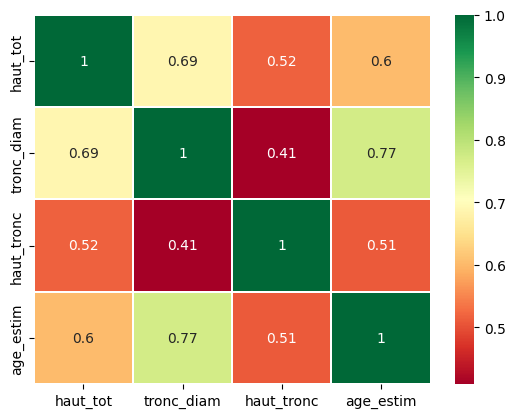

In [12]:
data_num.corr()
import seaborn as sns
sns.heatmap(data_num.corr(), annot=True, cmap='RdYlGn', linewidths=0.2)
plt.show()

On choisit de garder les paramètres numériques tels que haut_tot, hautçtronc et tronc_diam

In [13]:
data_features = data_num[['haut_tot', 'haut_tronc', 'tronc_diam']]
data_target = data_num[['age_estim']]

Séparer en deux sets : entrainement et test (20% de test)

In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data_features, data_target, test_size=0.2)

### Prétraitement des données

Nous allons utiliser un `StandardScaler` pour normaliser les caractéristiques numériques (`haut_tot`, `haut_tronc`, `tronc_diam`). Cette étape est cruciale pour que le modèle n'attribue pas une importance disproportionnée aux caractéristiques ayant des valeurs plus grandes.

In [15]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train = x_train_scaled
x_test = x_test_scaled

joblib.dump(scaler, 'standard_scaler.pkl')
print("StandardScaler sauvegardé comme 'standard_scaler.pkl'")

StandardScaler sauvegardé comme 'standard_scaler.pkl'


Choix de l'algo d'apprentissage supervisé

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
from sklearn import tree

#model = tree.DecisionTreeRegressor()
model = RandomForestRegressor()
model.fit(x_train, y_train)

y_predict = model.predict(x_test)

mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
r2_score_val = r2_score(y_test, y_predict)
rmse = np.sqrt(mse)

print('mae', mae)
print('mse', mse)
print('r2_score', r2_score_val)
print('rmse', rmse)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


mae 6.740350357998256
mse 119.23842243979252
r2_score 0.7237990060406706
rmse 10.919634720987352


En moyenne, 10-11 ans d'écart avec la réalité

Chercher les meilleurs hyperparamètres pour le modèle

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np


param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log', None],
    'min_samples_split': [2, 5],
    'max_depth': [None, 15, 30],
    'min_samples_leaf': [1, 2, 4],
}


rfr = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rfr, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_absolute_error')

grid_search.fit(x_train, y_train.values.ravel())

print("Meilleurs paramètres : ", grid_search.best_params_)
print("Meilleure MAE : ", -grid_search.best_score_)

best_rfr_model = grid_search.best_estimator_
y_predict_best = best_rfr_model.predict(x_test)

mae_best = mean_absolute_error(y_test, y_predict_best)
mse_best = mean_squared_error(y_test, y_predict_best)
r2_score_best = r2_score(y_test, y_predict_best) # This line should now work after fixing the variable name conflict
rmse_best = np.sqrt(mse_best)

print('\nMetrics pour meilleur modèle:')
print('mae:', mae_best)
print('mse:', mse_best)
print('r2_score:', r2_score_best)
print('rmse:', rmse_best)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
108 fits failed out of a total of 324.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
108 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/util

Meilleurs paramètres :  {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Meilleure MAE :  6.817738197734006

Metrics pour meilleur modèle:
mae: 6.57107675815998
mse: 111.70678329259549
r2_score: 0.7412451125559527
rmse: 10.569142978150854


Récupérer le meilleur modèle

In [18]:
import joblib

# Save the best model
joblib.dump(best_rfr_model, 'best_random_forest_model.pkl')
print("Best model saved as 'best_random_forest_model.pkl'")

Best model saved as 'best_random_forest_model.pkl'
